In [1]:
%pip install rasterio
%pip install segmentation-models-pytorch torchmetrics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 15.1 MB/s eta 0:00:00


## **Patch Dataset Creation**

In [2]:
import os
import numpy as np
import rasterio
from rasterio.windows import Window
from sklearn.model_selection import train_test_split

# ==== CONFIGURATION ====
INPUT_STACK = "/content/drive/MyDrive/FloodRisk-Ibadan-DeepLearning/Sentinel_Stacks/scene2_dry_stack.tif"   # example Sentinel-2 stack
INPUT_MASK  = "/content/drive/MyDrive/FloodRisk-Ibadan-DeepLearning/Masks/scene2_dry_label.tif"             # corresponding mask
PATCH_SIZE = 256                                              # tile size (256x256)
OUTPUT_DIR = "dataset/tiles/"

# Create output folders
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(OUTPUT_DIR, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, split, "masks"), exist_ok=True)

# ==== STEP 1: Load data ====
with rasterio.open(INPUT_STACK) as src_img, rasterio.open(INPUT_MASK) as src_mask:
    img_array = src_img.read()   # shape: (bands, H, W)
    mask_array = src_mask.read(1)  # single band (H, W)

print("Image shape:", img_array.shape)  # e.g. (6 bands, 3000, 3000)
print("Mask shape:", mask_array.shape)

# ==== STEP 2: Extract patches ====
patches_img = []
patches_mask = []

height, width = mask_array.shape

for i in range(0, height, PATCH_SIZE):
    for j in range(0, width, PATCH_SIZE):
        # Crop window
        img_patch = img_array[:, i:i+PATCH_SIZE, j:j+PATCH_SIZE]
        mask_patch = mask_array[i:i+PATCH_SIZE, j:j+PATCH_SIZE]

        # Skip if patch is smaller than desired size (edge tiles)
        if img_patch.shape[1] != PATCH_SIZE or img_patch.shape[2] != PATCH_SIZE:
            continue

        # Skip patches with no water at all (optional, reduces imbalance)
        if mask_patch.sum() == 0:
            continue

        patches_img.append(img_patch)
        patches_mask.append(mask_patch)

print(f"Total patches extracted: {len(patches_img)}")

# ==== STEP 3: Split train/val/test ====
train_idx, test_idx = train_test_split(range(len(patches_img)), test_size=0.2, random_state=42)
train_idx, val_idx  = train_test_split(train_idx, test_size=0.1, random_state=42)

def save_patches(indices, split):
    for k, idx in enumerate(indices):
        np.save(os.path.join(OUTPUT_DIR, split, "images", f"img_{k}.npy"), patches_img[idx])
        np.save(os.path.join(OUTPUT_DIR, split, "masks", f"mask_{k}.npy"), patches_mask[idx])

save_patches(train_idx, "train")
save_patches(val_idx, "val")
save_patches(test_idx, "test")

print("✅ Patches saved into dataset/tiles/ folder")


Image shape: (6, 1251, 1134)
Mask shape: (1251, 1134)
Total patches extracted: 10
✅ Patches saved into dataset/tiles/ folder


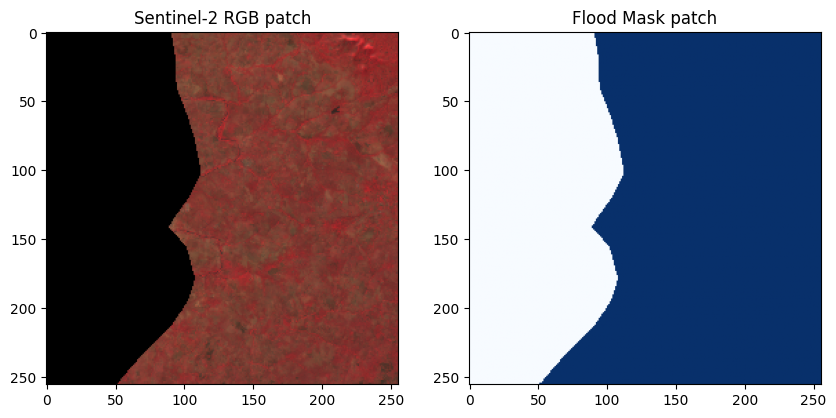

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Load one saved patch
img_patch = np.load("dataset/tiles/train/images/img_0.npy")  # shape: (6, 256, 256)
mask_patch = np.load("dataset/tiles/train/masks/mask_0.npy") # shape: (256, 256)

# Pick RGB bands (B4=Red, B3=Green, B2=Blue → indexes 3,2,1)
rgb = np.transpose(img_patch[[3,2,1], :, :], (1,2,0))

# Normalize for display
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(rgb)
plt.title("Sentinel-2 RGB patch")

plt.subplot(1,2,2)
plt.imshow(mask_patch, cmap="Blues")
plt.title("Flood Mask patch")

plt.show()


## **PyTorch Dataset Class**

In [4]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

class FloodDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        """
        Args:
            image_dir (str): path to image patches (numpy arrays).
            mask_dir (str): path to mask patches (numpy arrays).
            transform (albumentations.Compose): augmentations to apply.
        """
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_files = sorted(os.listdir(image_dir))
        self.mask_files = sorted(os.listdir(mask_dir))
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # Load image and mask
        image_path = os.path.join(self.image_dir, self.image_files[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_files[idx])

        image = np.load(image_path)  # shape: (C, H, W)
        mask = np.load(mask_path)    # shape: (H, W)

        # Convert to float32 for PyTorch
        image = image.astype(np.float32)
        mask = mask.astype(np.float32)

        # Transpose image to (H, W, C) for Albumentations
        image = np.transpose(image, (1, 2, 0))

        # Apply augmentations (if any)
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        else:
            # Convert to tensors if no augmentation
            image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)
            mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return image, mask


##**Augmentations**

Use `Albumentations` for spatially consistent augmentations (applied to both image & mask):

In [5]:
# Define training augmentations
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=0.0, std=1.0, max_pixel_value=1.0),  # normalize to [0,1]
    ToTensorV2()
])

# Validation: only normalization
val_transform = A.Compose([
    A.Normalize(mean=0.0, std=1.0, max_pixel_value=1.0),
    ToTensorV2()
])


###**DataLoader**

In [6]:
# Paths
train_img_dir = "dataset/tiles/train/images"
train_mask_dir = "dataset/tiles/train/masks"
val_img_dir = "dataset/tiles/val/images"
val_mask_dir = "dataset/tiles/val/masks"

# Create datasets
train_dataset = FloodDataset(train_img_dir, train_mask_dir, transform=train_transform)
val_dataset = FloodDataset(val_img_dir, val_mask_dir, transform=val_transform)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2)

# Check a batch
for images, masks in train_loader:
    print("Image batch shape:", images.shape)  # [B, C, H, W]
    print("Mask batch shape:", masks.shape)    # [B, 1, H, W]
    break


Image batch shape: torch.Size([4, 6, 256, 256])
Mask batch shape: torch.Size([4, 256, 256])


##**🟢 Step 1 — Imports & Config**

In [7]:
# =============================
# STEP 1: Imports & Config
# =============================
import os
import numpy as np
import rasterio
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
import shutil, random

# Global constants
PATCH_SIZE = 256
OUTPUT_DIR = "dataset/tiles/"

# Ensure dataset folders exist
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(OUTPUT_DIR, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, split, "masks"), exist_ok=True)

# Paths to Sentinel stacks and masks
STACK_DIR = "/content/drive/MyDrive/FloodRisk-Ibadan-DeepLearning/Sentinel_Stacks"
MASK_DIR  = "/content/drive/MyDrive/FloodRisk-Ibadan-DeepLearning/Masks"

# Stack–mask pairs (dry/rainy, multiple scenes)
pairs = [
    ("ibadan_2023_dry_stack.tif",   "ibadan_2023_dry_label.tif"),
    ("ibadan_2023_rainy_stack.tif", "ibadan_2023_rainy_label.tif"),
    ("scene1_dry_stack.tif", "scene1_dry_label.tif"),
    ("scene1_rainy_stack.tif", "scene1_rainy_label.tif"),
    ("scene2_dry_stack.tif", "scene2_dry_label.tif"),
    ("scene2_rainy_stack.tif", "scene2_rainy_label.tif"),
    ("scene3_dry_stack.tif", "scene3_dry_label.tif"),
    ("scene3_rainy_stack.tif", "scene3_rainy_label.tif"),
    ("scene4_dry_stack.tif", "scene4_dry_label.tif"),
    ("scene4_rainy_stack.tif", "scene4_rainy_label.tif"),
    ("scene5_dry_stack.tif", "scene5_dry_label.tif"),
    ("scene5_rainy_stack.tif", "scene5_rainy_label.tif"),
    ("scene6_rainy_stack.tif", "scene6_rainy_label.tif"),
    ("scene7_rainy_stack.tif", "scene7_rainy_label.tif"),
    ("scene8_rainy_stack.tif", "scene8_rainy_label.tif"),
    ("scene9_rainy_stack.tif", "scene9_rainy_label.tif"),
]


##**🟢 Step 2 — Patch Extraction & Saving**

In [8]:
# =============================
# STEP 2: Extract patches
# =============================

patches_img = []
patches_mask = []

for stack_file, mask_file in pairs:
    with rasterio.open(os.path.join(STACK_DIR, stack_file)) as src_img, \
         rasterio.open(os.path.join(MASK_DIR, mask_file)) as src_mask:

        img_array = src_img.read()   # (bands, H, W)
        mask_array = src_mask.read(1)
        h, w = mask_array.shape

        # Sliding window extraction
        for i in range(0, h, PATCH_SIZE):
            for j in range(0, w, PATCH_SIZE):
                img_patch = img_array[:, i:i+PATCH_SIZE, j:j+PATCH_SIZE]
                mask_patch = mask_array[i:i+PATCH_SIZE, j:j+PATCH_SIZE]

                # Skip incomplete or empty patches
                if img_patch.shape[1] != PATCH_SIZE or img_patch.shape[2] != PATCH_SIZE:
                    continue
                if mask_patch.sum() == 0:
                    continue

                patches_img.append(img_patch)
                patches_mask.append(mask_patch)

print(f"✅ Total patches collected: {len(patches_img)}")

# ---- Train/Val/Test Split ----
train_idx, test_idx = train_test_split(range(len(patches_img)), test_size=0.2, random_state=42)
train_idx, val_idx  = train_test_split(train_idx, test_size=0.1, random_state=42)

def save_patches(indices, split):
    for k, idx in enumerate(indices):
        np.save(os.path.join(OUTPUT_DIR, split, "images", f"img_{split}_{k}.npy"), patches_img[idx])
        np.save(os.path.join(OUTPUT_DIR, split, "masks", f"mask_{split}_{k}.npy"), patches_mask[idx])

save_patches(train_idx, "train")
save_patches(val_idx, "val")
save_patches(test_idx, "test")

print("🎉 All patches saved in dataset/tiles/")


✅ Total patches collected: 166
🎉 All patches saved in dataset/tiles/


##**🟢 Step 3 — Mask Cleaning (One-Time)**

In [9]:
# =============================
# STEP 3: Mask cleaning
# =============================
MASK_DIRS = [
    "dataset/tiles/train/masks",
    "dataset/tiles/val/masks",
    "dataset/tiles/test/masks"
]

def clean_and_binarize_masks():
    for mask_dir in MASK_DIRS:
        files = [f for f in os.listdir(mask_dir) if f.endswith(".npy")]
        for f in files:
            path = os.path.join(mask_dir, f)
            mask = np.load(path)
            mask_bin = (mask > 0.5).astype(np.uint8)
            np.save(path, mask_bin)
        print(f"✅ Cleaned {len(files)} masks in {mask_dir}")

clean_and_binarize_masks()

# Verify
for mask_dir in MASK_DIRS:
    files = os.listdir(mask_dir)[:5]
    for f in files:
        mask = np.load(os.path.join(mask_dir, f))
        print(f"{mask_dir}/{f} unique values:", np.unique(mask))


✅ Cleaned 125 masks in dataset/tiles/train/masks
✅ Cleaned 15 masks in dataset/tiles/val/masks
✅ Cleaned 36 masks in dataset/tiles/test/masks
dataset/tiles/train/masks/mask_train_90.npy unique values: [0]
dataset/tiles/train/masks/mask_train_28.npy unique values: [0 1]
dataset/tiles/train/masks/mask_train_79.npy unique values: [0]
dataset/tiles/train/masks/mask_train_65.npy unique values: [0]
dataset/tiles/train/masks/mask_train_114.npy unique values: [0]
dataset/tiles/val/masks/mask_val_7.npy unique values: [0]
dataset/tiles/val/masks/mask_val_2.npy unique values: [0]
dataset/tiles/val/masks/mask_val_1.npy unique values: [0]
dataset/tiles/val/masks/mask_val_0.npy unique values: [0]
dataset/tiles/val/masks/mask_val_8.npy unique values: [0]
dataset/tiles/test/masks/mask_test_7.npy unique values: [0]
dataset/tiles/test/masks/mask_test_25.npy unique values: [0]
dataset/tiles/test/masks/mask_test_22.npy unique values: [0]
dataset/tiles/test/masks/mask_test_20.npy unique values: [0]
dataset

##**🟢 Step 4 — Dataset Class**

In [10]:
# =============================
# STEP 4: Custom Dataset
# =============================
class FloodDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None, skip_empty=True):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_files = sorted(os.listdir(image_dir))
        self.mask_files = sorted(os.listdir(mask_dir))
        self.transform = transform

        # Filter out empty masks if needed
        if skip_empty:
            valid_idx = []
            for i, mf in enumerate(self.mask_files):
                mask = np.load(os.path.join(mask_dir, mf))
                if np.any(mask > 0):
                    valid_idx.append(i)
            self.image_files = [self.image_files[i] for i in valid_idx]
            self.mask_files = [self.mask_files[i] for i in valid_idx]
            print(f"✅ Kept {len(self.mask_files)} patches after removing empties")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img = np.load(os.path.join(self.image_dir, self.image_files[idx])).astype(np.float32)
        mask = np.load(os.path.join(self.mask_dir, self.mask_files[idx])).astype(np.float32)

        # Albumentations wants (H, W, C)
        img = np.transpose(img, (1, 2, 0))

        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img = aug['image']
            mask = aug['mask'].unsqueeze(0)  # (1, H, W)
        else:
            img = torch.tensor(img).permute(2, 0, 1)
            mask = torch.tensor(mask).unsqueeze(0)

        return img, mask


##**🟢 Step 5 — Transforms & Augmentations**

In [11]:
# =============================
# STEP 5: Transforms
# =============================
train_transform = A.Compose([
    A.RandomCrop(256, 256),            # random tiles
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=0.0, std=1.0, max_pixel_value=1.0),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Normalize(mean=0.0, std=1.0, max_pixel_value=1.0),
    ToTensorV2()
])


##**🟢 Step 6 — Dataloaders**

In [12]:
# =============================
# STEP 6: Datasets & Dataloaders
# =============================
train_dataset = FloodDataset("dataset/tiles/train/images",
                             "dataset/tiles/train/masks",
                             transform=train_transform,
                             skip_empty=True)

val_dataset = FloodDataset("dataset/tiles/val/images",
                           "dataset/tiles/val/masks",
                           transform=val_transform,
                           skip_empty=True)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2)

# Quick sanity check
for imgs, masks in train_loader:
    print("Image batch:", imgs.shape)  # [B, C, 256, 256]
    print("Mask batch:", masks.shape)  # [B, 1, 256, 256]
    print("Mask unique values:", torch.unique(masks))
    break


✅ Kept 14 patches after removing empties
✅ Kept 1 patches after removing empties
Image batch: torch.Size([4, 6, 256, 256])
Mask batch: torch.Size([4, 1, 256, 256])
Mask unique values: tensor([0., 1.])


##**🟢 Step 7 — Balancing Sampling**

In [13]:
# =============================
# STEP 7: Balanced Sampling
# =============================
# Compute weights: patches with floods = higher weight
def compute_class_weights(dataset, positive_weight=5.0, negative_weight=1.0):
    weights = []
    for i in range(len(dataset)):
        _, mask = dataset[i]
        if mask.sum() > 0:   # flood present
            weights.append(positive_weight)
        else:                # no flood
            weights.append(negative_weight)
    return weights

# Apply to training set
train_weights = compute_class_weights(train_dataset)
train_sampler = WeightedRandomSampler(train_weights, num_samples=len(train_weights), replacement=True)

# Rebuild train_loader with sampler
train_loader = DataLoader(train_dataset, batch_size=4, sampler=train_sampler, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2)

print("✅ Balanced DataLoader created with WeightedRandomSampler")


✅ Balanced DataLoader created with WeightedRandomSampler


##**🟢 Step 8 — Model, Loss & Training Setup**

###**8A. Model Definition (U-Net with ResNet18 encoder)**

In [14]:
# =============================
# STEP 8A: Model Definition
# =============================
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp

# Define U-Net model
# - Encoder: ResNet18 (can switch to ResNet34 later)
# - No pretrained weights (Sentinel is not RGB)
# - Input channels = 6 Sentinel bands
# - Output = binary mask (flood vs background)
model = smp.Unet(
    encoder_name="resnet50",
    encoder_weights=None,  # "imagenet" = Transfer learning
    in_channels=6,
    classes=1,
    activation=None
)

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"✅ Model initialized on {device}")


✅ Model initialized on cpu


###**8B. Loss Function (BCE + Dice)**

In [15]:
# =============================
# STEP 8B: Loss Function
# =============================

# Dice Loss handles overlap between prediction and ground truth
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = torch.sigmoid(preds)   # apply sigmoid
        preds = preds.view(-1)
        targets = targets.view(-1)

        intersection = (preds * targets).sum()
        dice = (2. * intersection + self.smooth) / (preds.sum() + targets.sum() + self.smooth)
        return 1 - dice

# Compute class imbalance ratio from training masks
print("⚡ Computing flood vs background ratio...")
all_masks = torch.cat([mask.flatten() for _, mask in train_dataset])
flood_ratio = (all_masks == 1).sum().float() / all_masks.numel()
non_flood_ratio = 1 - flood_ratio
print(f"Flood ratio: {flood_ratio:.4f}, Non-flood ratio: {non_flood_ratio:.4f}")


# Weighted BCE (to give more importance to flooded pixels)
pos_weight = torch.tensor([5.0]).to(device)  # flood pixels 5x more important
bce  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
dice = DiceLoss()

# Combine BCE + Dice
def bce_dice_loss(preds, targets):
    return bce(preds, targets) + dice(preds, targets)


⚡ Computing flood vs background ratio...
Flood ratio: 0.0101, Non-flood ratio: 0.9899


###**8C. Metrics (IoU & F1)**

In [16]:
# =============================
# STEP 8C: Metrics (IoU & F1)
# =============================
from torchmetrics.classification import BinaryJaccardIndex, BinaryF1Score

iou_metric = BinaryJaccardIndex().to(device)  # Intersection over Union
f1_metric  = BinaryF1Score().to(device)       # F1 Score


###**8D. Optimize + Scheduler**

In [17]:
# =============================
# STEP 8D: Optimizer + Scheduler
# =============================
import torch
from torch import optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5
)

###**8E. Training & Evaluation Functions**

In [18]:
# =============================
# STEP 8E: Training & Evaluation
# =============================

# Train one epoch
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0

    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = bce_dice_loss(outputs, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


# Evaluate (compute IoU & F1)
def evaluate(model, loader, device):
    model.eval()
    total_iou, total_f1, n_batches = 0, 0, 0

    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            preds = torch.sigmoid(outputs)

            total_iou += iou_metric(preds, masks).item()
            total_f1  += f1_metric(preds, masks).item()
            n_batches += 1

    return total_iou / n_batches, total_f1 / n_batches


###**8F. Run Baseline Training**

⚠️ Notice: we already created `train_loader` and `val_loader` in Step 7 (balanced sampler).
So here we just reuse them.

In [19]:
## -------------------------------
## STEP 8F. Data Loaders
## -------------------------------
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=4, shuffle=False)

###**8G. Run Training**

In [20]:
# =============================
# STEP 8G: Training Loop (with scheduler + checkpointing)
# =============================
EPOCHS = 100   # increased from 10 → 50
best_iou = 0

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_iou, val_f1 = evaluate(model, val_loader, device)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | "
          f"Val IoU: {val_iou:.4f} | Val F1: {val_f1:.4f}")

    # Step scheduler using validation IoU
    scheduler.step(val_iou)

    # Save best model
    if val_iou > best_iou:
        torch.save(model.state_dict(), "baseline_unet_resnet18.pth")
        best_iou = val_iou
        print("✅ Saved new best model")
        print("✅ Saved new best model")


Epoch 1/100 | Train Loss: 1.7196 | Val IoU: 0.0169 | Val F1: 0.0333
✅ Saved new best model
✅ Saved new best model
Epoch 2/100 | Train Loss: 1.5348 | Val IoU: 0.0156 | Val F1: 0.0307
Epoch 3/100 | Train Loss: 1.4191 | Val IoU: 0.0000 | Val F1: 0.0000
Epoch 4/100 | Train Loss: 1.3308 | Val IoU: 0.0000 | Val F1: 0.0000
Epoch 5/100 | Train Loss: 1.2743 | Val IoU: 0.0000 | Val F1: 0.0000
Epoch 6/100 | Train Loss: 1.2393 | Val IoU: 0.1089 | Val F1: 0.1964
✅ Saved new best model
✅ Saved new best model
Epoch 7/100 | Train Loss: 1.1552 | Val IoU: 0.0292 | Val F1: 0.0567
Epoch 8/100 | Train Loss: 1.1650 | Val IoU: 0.1434 | Val F1: 0.2508
✅ Saved new best model
✅ Saved new best model
Epoch 9/100 | Train Loss: 1.1672 | Val IoU: 0.0000 | Val F1: 0.0000
Epoch 10/100 | Train Loss: 1.0670 | Val IoU: 0.1637 | Val F1: 0.2814
✅ Saved new best model
✅ Saved new best model
Epoch 11/100 | Train Loss: 1.0480 | Val IoU: 0.2052 | Val F1: 0.3406
✅ Saved new best model
✅ Saved new best model
Epoch 12/100 | Train